In [1]:
import pandas as pd

df = pd.read_excel("../data/sales_data.xlsx")

print(df.head())

        State       Date      Total   Category
0     Alabama 2019-12-01  109574036  Beverages
1     Arizona 2019-12-01  109101595  Beverages
2    Arkansas 2019-12-01   58049432  Beverages
3  California 2019-12-01  444766891  Beverages
4    Colorado 2019-12-01   89816716  Beverages


In [2]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(8084, 4)
<class 'pandas.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   State     8084 non-null   str           
 1   Date      8084 non-null   datetime64[us]
 2   Total     8084 non-null   int64         
 3   Category  8084 non-null   str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 252.8 KB
None
State       0
Date        0
Total       0
Category    0
dtype: int64


In [3]:
df = df.sort_values(by=['State', 'Date'])

print(df.head())

        State       Date      Total   Category
86    Alabama 2019-10-06  129106730  Beverages
3397  Alabama 2019-10-13  123782286  Beverages
5246  Alabama 2019-10-20  116218909  Beverages
7095  Alabama 2019-10-27  109968011  Beverages
43    Alabama 2019-11-03  112189104  Beverages


In [4]:
df['month'] = df['Date'].dt.month

df['day_of_week'] = df['Date'].dt.dayofweek

df['quarter'] = df['Date'].dt.quarter

print(df[['Date', 'month', 'day_of_week', 'quarter']].head())

           Date  month  day_of_week  quarter
86   2019-10-06     10            6        4
3397 2019-10-13     10            6        4
5246 2019-10-20     10            6        4
7095 2019-10-27     10            6        4
43   2019-11-03     11            6        4


In [5]:
df['lag_1'] = df.groupby('State')['Total'].shift(1)

df['lag_7'] = df.groupby('State')['Total'].shift(7)

df['lag_30'] = df.groupby('State')['Total'].shift(30)

print(df[['State', 'Date', 'Total', 'lag_1', 'lag_7', 'lag_30']].head(35))

        State       Date      Total        lag_1        lag_7       lag_30
86    Alabama 2019-10-06  129106730          NaN          NaN          NaN
3397  Alabama 2019-10-13  123782286  129106730.0          NaN          NaN
5246  Alabama 2019-10-20  116218909  123782286.0          NaN          NaN
7095  Alabama 2019-10-27  109968011  116218909.0          NaN          NaN
43    Alabama 2019-11-03  112189104  109968011.0          NaN          NaN
172   Alabama 2019-11-10  110932913  112189104.0          NaN          NaN
4472  Alabama 2019-11-17  109056410  110932913.0          NaN          NaN
6321  Alabama 2019-11-24  113040422  109056410.0  129106730.0          NaN
0     Alabama 2019-12-01  109574036  113040422.0  123782286.0          NaN
129   Alabama 2019-12-08  108083724  109574036.0  116218909.0          NaN
3956  Alabama 2019-12-15  108528456  108083724.0  109968011.0          NaN
5805  Alabama 2019-12-22  116541575  108528456.0  112189104.0          NaN
7654  Alabama 2019-12-29 

In [6]:
df['rolling_mean_7'] = df.groupby('State')['Total'].transform(
    lambda x: x.rolling(7).mean()
)

df['rolling_std_7'] = df.groupby('State')['Total'].transform(
    lambda x: x.rolling(7).std()
)

print(df[['Total', 'rolling_mean_7', 'rolling_std_7']].head(15))

          Total  rolling_mean_7  rolling_std_7
86    129106730             NaN            NaN
3397  123782286             NaN            NaN
5246  116218909             NaN            NaN
7095  109968011             NaN            NaN
43    112189104             NaN            NaN
172   110932913             NaN            NaN
4472  109056410    1.158935e+08   7.714872e+06
6321  113040422    1.135983e+08   5.062777e+06
0     109574036    1.115685e+08   2.497733e+06
129   108083724    1.104064e+08   1.755735e+06
3956  108528456    1.102007e+08   1.894466e+06
5805  116541575    1.108225e+08   3.029864e+06
7654  106949922    1.102535e+08   3.361519e+06
473   104239954    1.095654e+08   4.066419e+06
989   108717628    1.089479e+08   3.768032e+06


In [7]:
df = df.dropna()

print(df.isnull().sum())

print(df.shape)

State             0
Date              0
Total             0
Category          0
month             0
day_of_week       0
quarter           0
lag_1             0
lag_7             0
lag_30            0
rolling_mean_7    0
rolling_std_7     0
dtype: int64
(6794, 12)


In [8]:
train = df[df['Date'] < '2020-01-01']

test = df[df['Date'] >= '2020-01-01']

print("Train Shape:", train.shape)

print("Test Shape:", test.shape)

Train Shape: (0, 12)
Test Shape: (6794, 12)


In [9]:
print(df['Date'].min())

print(df['Date'].max())

2020-05-03 00:00:00
2023-05-07 00:00:00


In [10]:
train = df[df['Date'] < '2022-01-01']

test = df[df['Date'] >= '2022-01-01']

print("Train Shape:", train.shape)

print("Test Shape:", test.shape)

Train Shape: (3741, 12)
Test Shape: (3053, 12)


In [11]:
features = [
    'month',
    'day_of_week',
    'quarter',
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7'
]

X_train = train[features]

y_train = train['Total']

X_test = test[features]

y_test = test['Total']

print(X_train.shape)

print(X_test.shape)

(3741, 8)
(3053, 8)


In [12]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [13]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 35690164.536706075


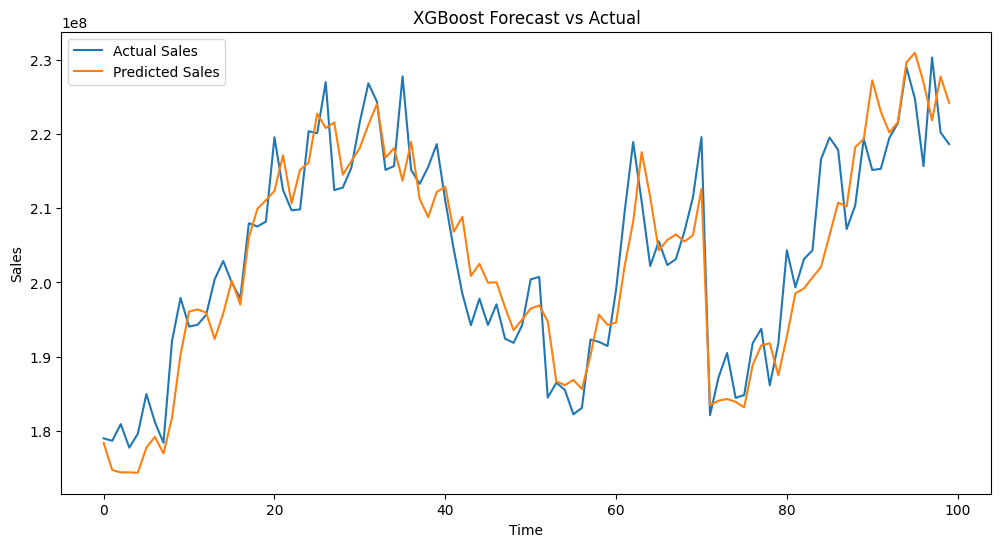

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual Sales')

plt.plot(pred_xgb[:100], label='Predicted Sales')

plt.title('XGBoost Forecast vs Actual')

plt.xlabel('Time')

plt.ylabel('Sales')

plt.legend()

plt.show()

In [15]:
results = pd.DataFrame({
    'Actual_Sales': y_test.values,
    'Predicted_Sales': pred_xgb
})

results.to_csv("../outputs/xgboost_predictions.csv", index=False)

print(results.head())

   Actual_Sales  Predicted_Sales
0     179002839      178380240.0
1     178676924      174736672.0
2     180918293      174424768.0
3     177754219      174420016.0
4     179630073      174377392.0


In [17]:
prophet_train = train[['Date', 'Total']].copy()

prophet_train.columns = ['ds', 'y']

print(prophet_train.head())

             ds          y
387  2020-05-03  128066131
903  2020-05-10  127906087
4343 2020-05-17  130340051
6192 2020-05-24  134708619
7955 2020-05-31  129887877


In [18]:
model_prophet = Prophet()

model_prophet.fit(prophet_train)

print("Prophet Model Trained Successfully")

15:52:35 - cmdstanpy - INFO - Chain [1] start processing
15:52:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Trained Successfully


In [19]:
future = model_prophet.make_future_dataframe(
    periods=8,
    freq='W'
)

forecast_prophet = model_prophet.predict(future)

print(forecast_prophet[['ds', 'yhat']].tail(8))

           ds          yhat
87 2022-01-02  1.939678e+08
88 2022-01-09  1.955846e+08
89 2022-01-16  1.972014e+08
90 2022-01-23  1.988182e+08
91 2022-01-30  2.004349e+08
92 2022-02-06  2.020517e+08
93 2022-02-13  2.036685e+08
94 2022-02-20  2.052853e+08


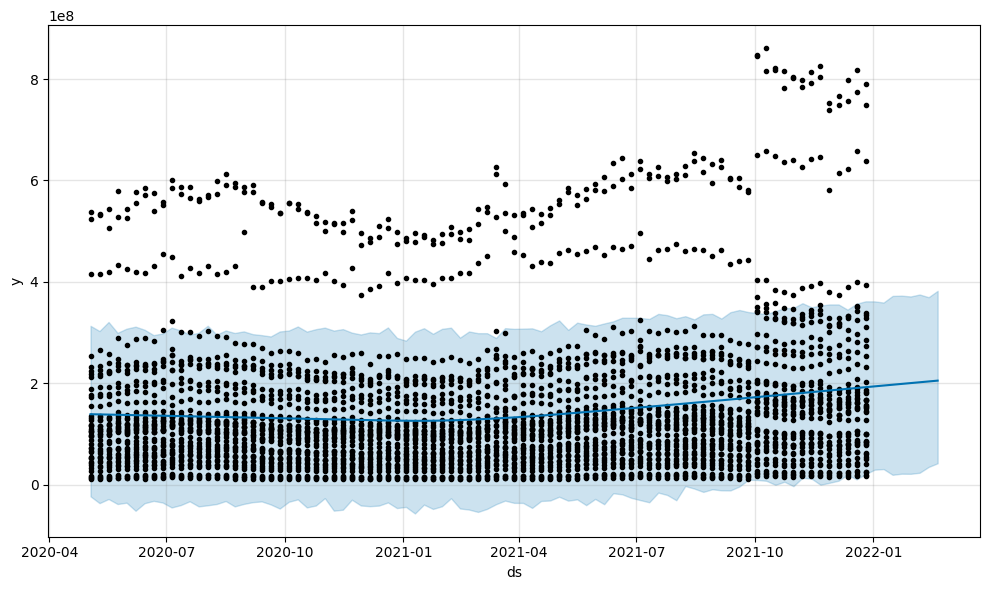

In [20]:
fig = model_prophet.plot(forecast_prophet)

In [21]:
forecast_prophet[['ds', 'yhat']].to_csv(
    "../outputs/prophet_forecast.csv",
    index=False
)

print("Prophet forecast saved successfully")

Prophet forecast saved successfully


In [22]:
california_df = df[df['State'] == 'California']

california_df = california_df.sort_values('Date')

print(california_df[['Date', 'Total']].head())

           Date      Total
390  2020-05-03  523453599
906  2020-05-10  532766128
4346 2020-05-17  506672448
6195 2020-05-24  528426454
7958 2020-05-31  525499509


In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    california_df['Total'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

print("SARIMA Model Trained Successfully")

C:\Users\91636\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\91636\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


SARIMA Model Trained Successfully


In [25]:
sarima_forecast = sarima_result.forecast(steps=8)

print(sarima_forecast)

158    8.692875e+08
159    8.662643e+08
160    8.867647e+08
161    9.282061e+08
162    8.911001e+08
163    8.624174e+08
164    8.740870e+08
165    8.990516e+08
Name: predicted_mean, dtype: float64


C:\Users\91636\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\91636\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [26]:
sarima_forecast_df = pd.DataFrame({
    'Forecasted_Sales': sarima_forecast
})

sarima_forecast_df.to_csv(
    "../outputs/sarima_forecast.csv",
    index=False
)

print(sarima_forecast_df)

     Forecasted_Sales
158      8.692875e+08
159      8.662643e+08
160      8.867647e+08
161      9.282061e+08
162      8.911001e+08
163      8.624174e+08
164      8.740870e+08
165      8.990516e+08


In [27]:
import joblib

joblib.dump(model_xgb, "../models/xgboost_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
